In [68]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [69]:
df =pd.read_csv("Salary.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [70]:
df.shape

(35, 2)

In [71]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 688.0 bytes


In [73]:
df.describe()

,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


In [74]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [75]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [76]:
print(X.shape)
print(y.shape)

(35, 1)
(35,)


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [78]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(28, 1)
(7, 1)
(28,)
(7,)


In [79]:
model = LinearRegression()

In [80]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8578.77]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.908e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [81]:
y_pred = model.predict(X_test)

In [82]:
comparison = pd.DataFrame({"Actual Salary": y_test.values, "Predicted Salary": y_pred})
comparison

,Actual Salary,Predicted Salary
0,116969,110576.917063
1,57081,64251.572689
2,109431,103713.903082
3,98273,89987.875119
4,67938,71114.586670
5,121872,119155.684540
6,93940,80551.230895


In [83]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 6692.364094497284
MSE: 55761791.306260146
RMSE: 7467.381824057221
R2 Score: 0.8914234140042779


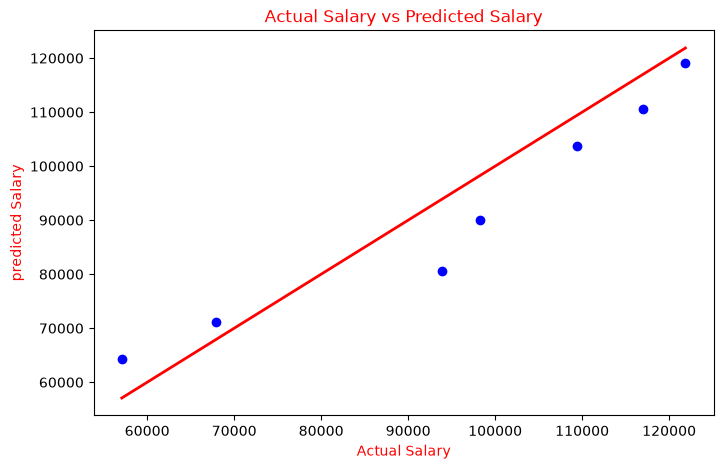

In [91]:
plt.figure(figsize = (8,5))

plt.scatter(y_test, y_pred, color = "blue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = "red",
    linewidth = 2
)


plt.xlabel("Actual Salary",color = "red")
plt.ylabel("predicted Salary", color = "red")

plt.title("Actual Salary vs Predicted Salary", color = "red")
plt.show()



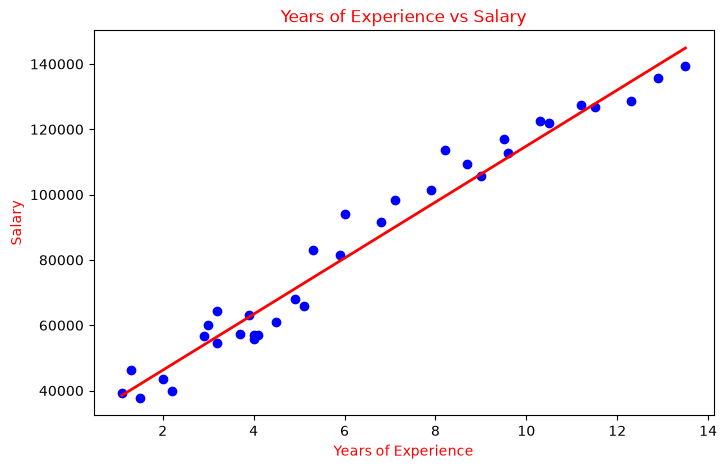

In [93]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, color="blue")

plt.plot(
    X,
    model.predict(X),
    color="red",
    linewidth=2
)

plt.xlabel("Years of Experience",color = "red")
plt.ylabel("Salary", color = "red")
plt.title("Years of Experience vs Salary", color = "red")

plt.show()

In [94]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 8578.767476685925
Intercept: 29078.626034406887


## Conclusion

In this project, I built a Linear Regression model to predict salary based on years of experience.

The dataset was divided into training and testing sets, and the model was trained using the training data.

The model achieved an R² score of 0.8914 on the test data, showing a strong linear relationship between years of experience and salary.

The Actual vs Predicted graph helped visualize the model's prediction performance.

The learned coefficient was approximately 8578.77, meaning that the model predicts an increase of about ₹8,579 in salary for each additional year of experience.

Overall, this project helped me practice the complete Linear Regression workflow from data loading and exploration to training, prediction, evaluation, visualization, and interpretation.
